In [13]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data_dir = Path('../data/processed/nhanes')
input_path = data_dir / 'seqn_unique_female.csv'
output_path = data_dir / 'diabetes_01_analysis.csv'

raw_data = pd.read_csv(input_path, encoding='utf-8-sig', low_memory=False)
sas_missing_marker = 5.397605346934028e-79
numeric_columns = raw_data.select_dtypes(include='number').columns
raw_data[numeric_columns] = raw_data[numeric_columns].replace(sas_missing_marker, float('nan'))

target_column = 'DIQ_L__DIQ010'
analysis_columns = [
    'SEQN', 'DEMO_L__RIDAGEYR', 'BMX_L__BMXWT', 'BMX_L__BMXHT',
    'BMX_L__BMXBMI', 'BMX_L__BMXWAIST', 'BPXO_L__BPXOSY1',
    'BPXO_L__BPXODI1', 'GHB_L__LBXGH', 'TCHOL_L__LBXTC',
    'HDL_L__LBDHDD', target_column
]

missing_columns = [column for column in analysis_columns if column not in raw_data.columns]
if missing_columns:
    raise KeyError(f'Missing required columns: {missing_columns}')

analysis_data = raw_data[analysis_columns].copy()
analysis_data['diabetes_target'] = analysis_data[target_column].map({1.0: 1, 2.0: 0})
model_analysis_data = analysis_data.dropna(subset=['diabetes_target']).copy()

analysis_data.to_csv(output_path, index=False, encoding='utf-8-sig')
sns.set_theme(style='whitegrid', context='notebook')
print('Source shape:', raw_data.shape)
print('Filtered analysis shape:', analysis_data.shape)
print('Rows with valid target:', model_analysis_data.shape[0])
print('Output file:', output_path.resolve())
print(analysis_data[target_column].value_counts(dropna=False).sort_index().to_string())

Source shape: (6358, 862)
Filtered analysis shape: (6358, 13)
Rows with valid target: 6114
Output file: D:\projects\tech-challenge-11iadt-fase-01\data\processed\nhanes\diabetes_01_analysis.csv
DIQ_L__DIQ010
1.0     557
2.0    5557
3.0     157
9.0       3
NaN      84


## Step 01 — Valores ausentes das variáveis selecionadas

As barras mostram quanto da amostra está disponível para cada variável. Por exemplo, cerca de 42% dos valores de HbA1c e 41% dos valores de colesterol estão ausentes; portanto, as distribuições desses exames representam apenas as participantes com medição disponível e não devem ser interpretadas como ausência da doença.

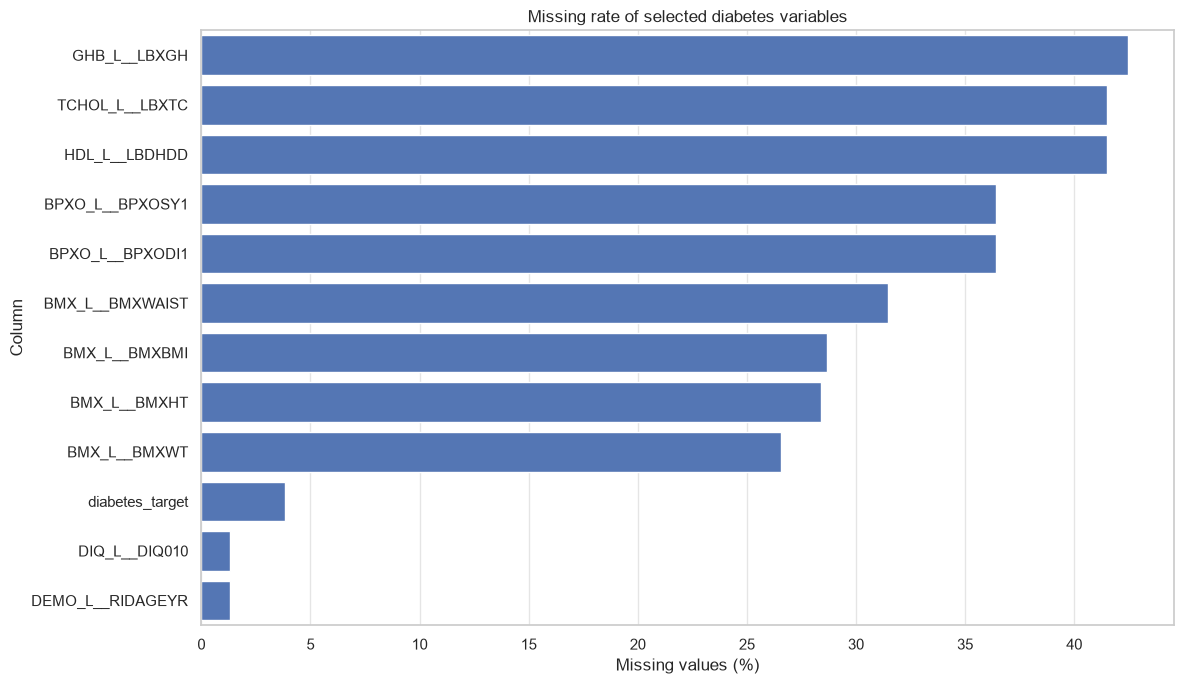

In [14]:
missing_rate = analysis_data.drop(columns=['SEQN']).isna().mean().sort_values(ascending=False).mul(100)
plt.figure(figsize=(12, 7))
sns.barplot(x=missing_rate.values, y=missing_rate.index, color='#4472C4')
plt.xlabel('Missing values (%)')
plt.ylabel('Column')
plt.title('Missing rate of selected diabetes variables')
plt.tight_layout()
plt.show()

## Step 02 — Distribuição do target candidato

O gráfico mostra 557 participantes classificadas como diabetes e 5.557 como no diabetes entre as 6.114 respostas válidas. Isso representa aproximadamente 9,1% de casos positivos e revela um target desbalanceado, situação em que accuracy isolada pode ser enganosa e recall e F1-score se tornam especialmente importantes.

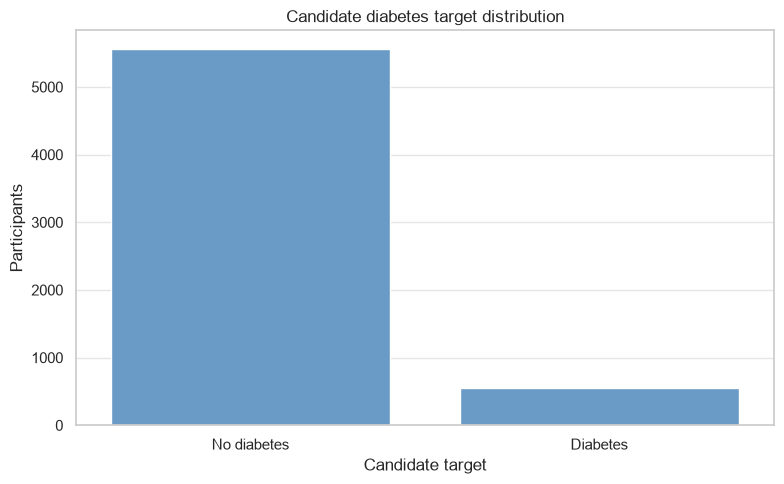

diabetes_target
0    5557
1     557


In [15]:
target_counts = model_analysis_data['diabetes_target'].value_counts().reindex([0, 1], fill_value=0)
plt.figure(figsize=(8, 5))
sns.barplot(x=['No diabetes', 'Diabetes'], y=target_counts.values, color='#5B9BD5')
plt.xlabel('Candidate target')
plt.ylabel('Participants')
plt.title('Candidate diabetes target distribution')
plt.tight_layout()
plt.show()
print(target_counts.to_string())

## Step 03 — Distribuição da idade

O histograma mostra uma amostra ampla, com idades entre 1 e 80 anos e mediana próxima de 40 anos. Como existem participantes menores de idade, a base atual não representa exclusivamente mulheres adultas; essa característica deverá ser considerada ao definir a população do modelo de diabetes.

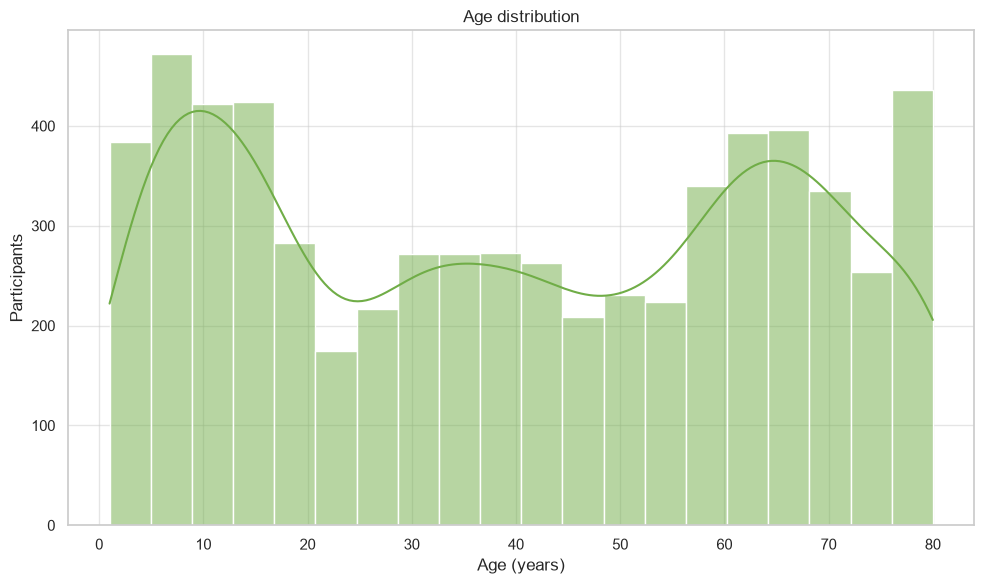

In [16]:
age_column = 'DEMO_L__RIDAGEYR'
age_data = analysis_data[age_column].dropna()
plt.figure(figsize=(10, 6))
sns.histplot(age_data, bins=20, kde=True, color='#70AD47')
plt.xlabel('Age (years)')
plt.ylabel('Participants')
plt.title('Age distribution')
plt.tight_layout()
plt.show()

## Step 04 — Distribuição do IMC

O histograma mostra a concentração dos valores de IMC e a linha tracejada indica a mediana, aproximadamente 26,6 kg/m². A cauda superior evidencia participantes com IMC elevado, mas o gráfico descreve a distribuição da amostra e não constitui diagnóstico individual de obesidade.

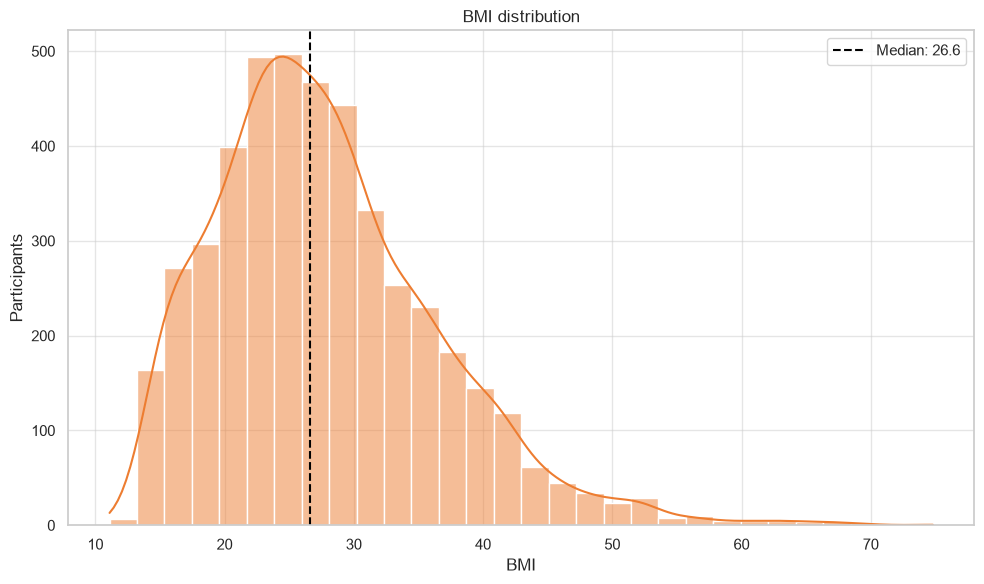

In [17]:
bmi_column = 'BMX_L__BMXBMI'
bmi_data = analysis_data[bmi_column].dropna()
plt.figure(figsize=(10, 6))
sns.histplot(bmi_data, bins=30, kde=True, color='#ED7D31')
plt.axvline(bmi_data.median(), color='black', linestyle='--', label=f'Median: {bmi_data.median():.1f}')
plt.xlabel('BMI')
plt.ylabel('Participants')
plt.title('BMI distribution')
plt.legend()
plt.tight_layout()
plt.show()

## Step 05 — Relação entre IMC e circunferência da cintura

Os pontos formam uma associação positiva muito forte: na amostra, a correlação de Spearman é aproximadamente 0,95, indicando que maiores circunferências da cintura tendem a ocorrer junto de maiores valores de IMC. Isso mostra redundância parcial entre as medidas, mas não prova que uma variável cause a outra.

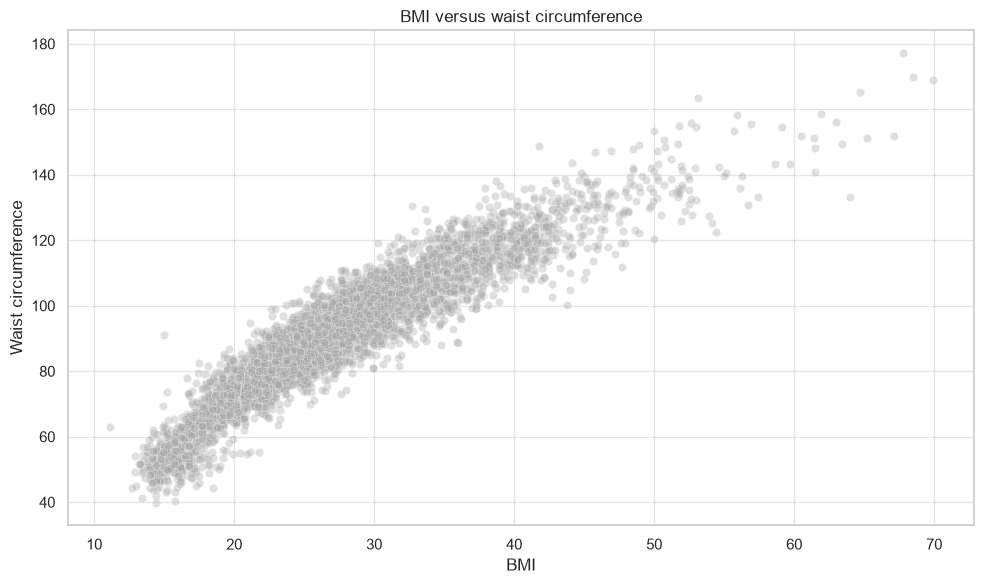

In [18]:
waist_column = 'BMX_L__BMXWAIST'
bmi_waist_data = analysis_data[[bmi_column, waist_column]].dropna()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=bmi_waist_data, x=bmi_column, y=waist_column, alpha=0.35, color='#A5A5A5')
plt.xlabel('BMI')
plt.ylabel('Waist circumference')
plt.title('BMI versus waist circumference')
plt.tight_layout()
plt.show()

## Step 06 — Distribuição da pressão arterial

O boxplot mostra a mediana, a dispersão e os valores extremos das duas medidas. A pressão sistólica tem mediana próxima de 113 e a diastólica próxima de 72; os pontos extremos indicam variabilidade que deve ser investigada, mas não permitem diagnosticar hipertensão individualmente.

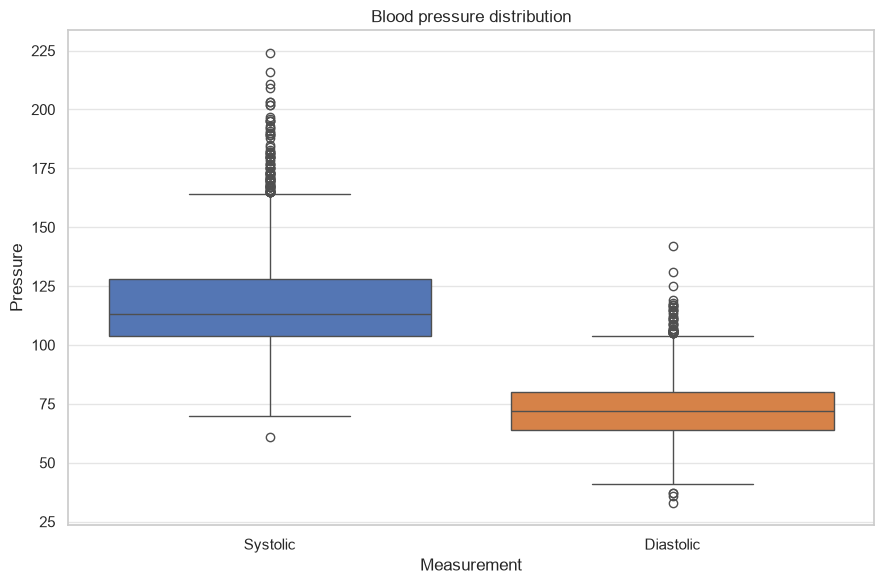

In [19]:
systolic_column = 'BPXO_L__BPXOSY1'
diastolic_column = 'BPXO_L__BPXODI1'
blood_pressure_data = analysis_data[[systolic_column, diastolic_column]].rename(columns={systolic_column: 'Systolic', diastolic_column: 'Diastolic'}).melt(var_name='measurement', value_name='pressure').dropna()
plt.figure(figsize=(9, 6))
sns.boxplot(data=blood_pressure_data, x='measurement', y='pressure', hue='measurement', legend=False, palette=['#4472C4', '#ED7D31'])
plt.xlabel('Measurement')
plt.ylabel('Pressure')
plt.title('Blood pressure distribution')
plt.tight_layout()
plt.show()

## Step 07 — Distribuição da hemoglobina glicada

O histograma mostra a concentração da HbA1c em torno de valores próximos de 5,5%, além de uma cauda de valores elevados. Como a HbA1c está diretamente relacionada ao controle glicêmico e pode ter sido medida no mesmo contexto do diagnóstico autorreferido, seu uso pode elevar artificialmente o desempenho e precisa ser tratado como possível vazamento de informação.

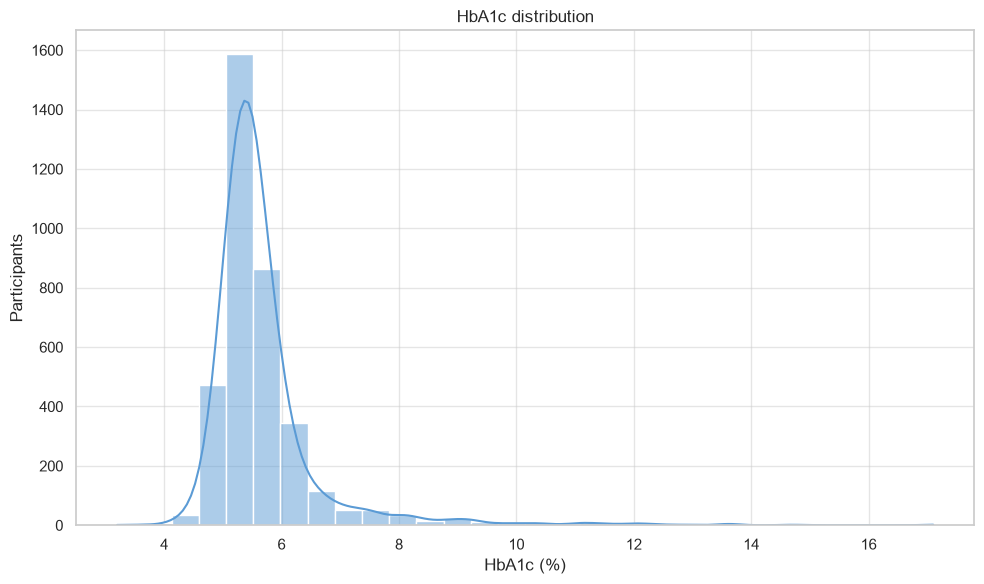

In [20]:
hba1c_column = 'GHB_L__LBXGH'
hba1c_data = analysis_data[hba1c_column].dropna()
plt.figure(figsize=(10, 6))
sns.histplot(hba1c_data, bins=30, kde=True, color='#5B9BD5')
plt.xlabel('HbA1c (%)')
plt.ylabel('Participants')
plt.title('HbA1c distribution')
plt.tight_layout()
plt.show()

## Step 08 — Distribuição do colesterol

O boxplot compara a posição central e a variabilidade do colesterol total e do HDL, que estão na mesma unidade de mg/dL. A comparação ajuda a identificar assimetrias e valores extremos, mas não deve ser usada isoladamente para classificar uma participante como doente ou saudável.

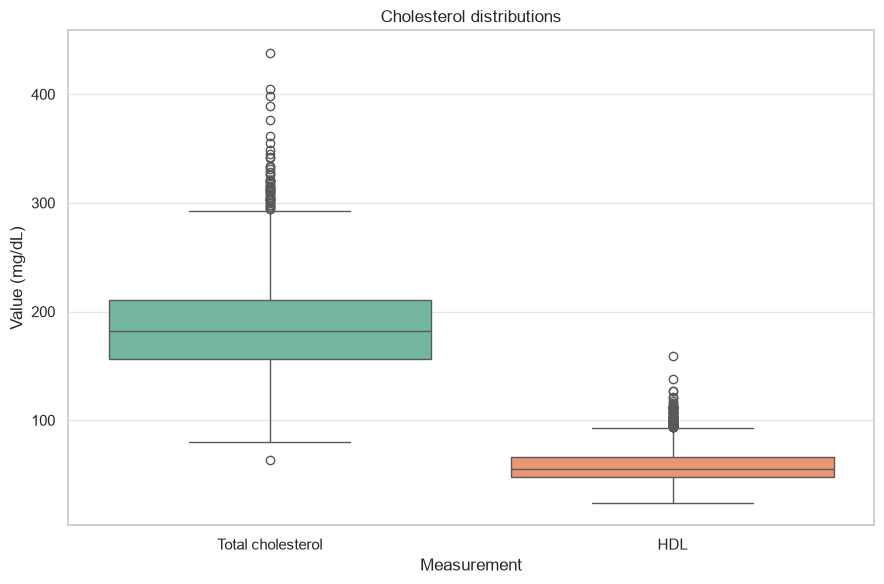

In [21]:
lipid_data = analysis_data[['TCHOL_L__LBXTC', 'HDL_L__LBDHDD']].rename(columns={'TCHOL_L__LBXTC': 'Total cholesterol', 'HDL_L__LBDHDD': 'HDL'}).melt(var_name='measurement', value_name='value').dropna()
plt.figure(figsize=(9, 6))
sns.boxplot(data=lipid_data, x='measurement', y='value', hue='measurement', legend=False, palette='Set2')
plt.xlabel('Measurement')
plt.ylabel('Value (mg/dL)')
plt.title('Cholesterol distributions')
plt.tight_layout()
plt.show()

## Step 09 — Heatmap de correlação clínica

As cores representam a intensidade e o sinal das associações monotônicas entre as variáveis. A relação IMC–circunferência da cintura é a mais forte, enquanto idade também apresenta associação positiva com IMC e cintura; essas correlações ajudam a detectar redundância entre features, mas não estabelecem causalidade nem substituem a avaliação clínica.

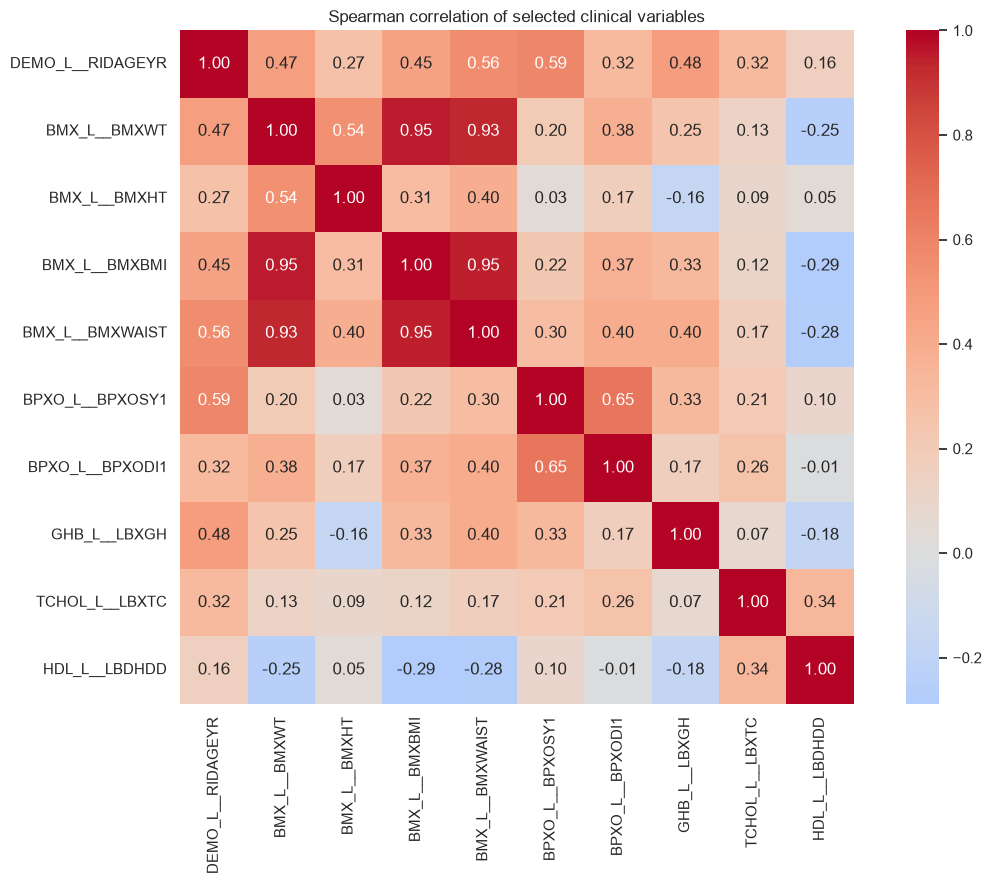

In [22]:
clinical_columns = ['DEMO_L__RIDAGEYR', 'BMX_L__BMXWT', 'BMX_L__BMXHT', 'BMX_L__BMXBMI', 'BMX_L__BMXWAIST', 'BPXO_L__BPXOSY1', 'BPXO_L__BPXODI1', 'GHB_L__LBXGH', 'TCHOL_L__LBXTC', 'HDL_L__LBDHDD']
clinical_correlation = analysis_data[clinical_columns].corr(method='spearman')
plt.figure(figsize=(12, 9))
sns.heatmap(clinical_correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Spearman correlation of selected clinical variables')
plt.tight_layout()
plt.show()

## Step 10 — IMC por target candidato de diabetes

O boxplot indica uma diferença importante entre os grupos: a mediana do IMC é aproximadamente 25,7 no grupo no diabetes e 33,3 no grupo diabetes. Essa diferença sugere associação entre IMC elevado e o target nesta amostra, mas não prova que o IMC cause diabetes e pode sofrer influência de idade, seleção amostral e valores ausentes.

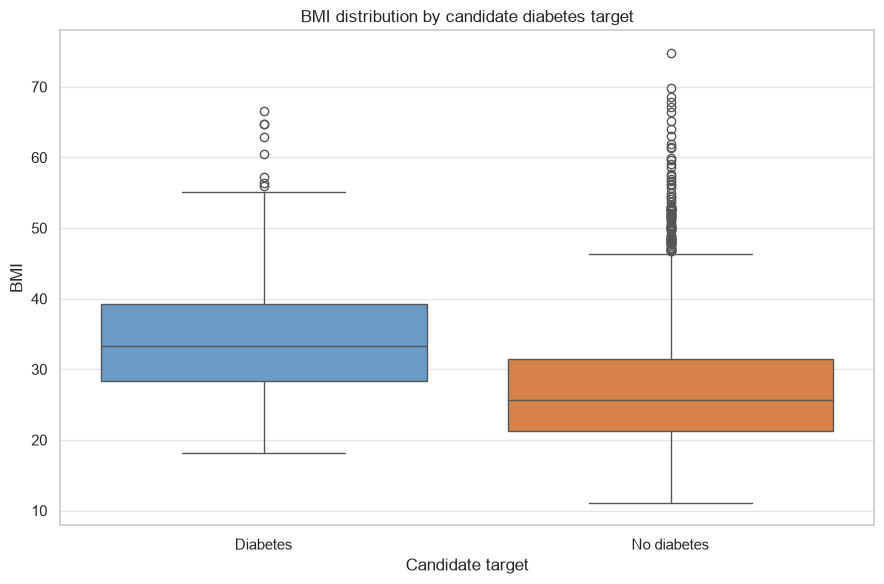

In [23]:
bmi_target_data = model_analysis_data[[bmi_column, 'diabetes_target']].dropna().copy()
bmi_target_data['target_label'] = bmi_target_data['diabetes_target'].map({0: 'No diabetes', 1: 'Diabetes'})
plt.figure(figsize=(9, 6))
sns.boxplot(data=bmi_target_data, x='target_label', y=bmi_column, hue='target_label', legend=False, palette=['#5B9BD5', '#ED7D31'])
plt.xlabel('Candidate target')
plt.ylabel('BMI')
plt.title('BMI distribution by candidate diabetes target')
plt.tight_layout()
plt.show()

## Step 11 — Hemoglobina glicada por target candidato de diabetes

O grupo diabetes apresenta mediana de HbA1c aproximadamente 6,9%, contra 5,4% no grupo no diabetes, considerando somente as observações com ambos os valores disponíveis. A separação é esperada porque HbA1c é uma medida diretamente relacionada à glicemia; por isso, o gráfico é útil para EDA, mas também reforça o risco de vazamento no modelo preditivo.

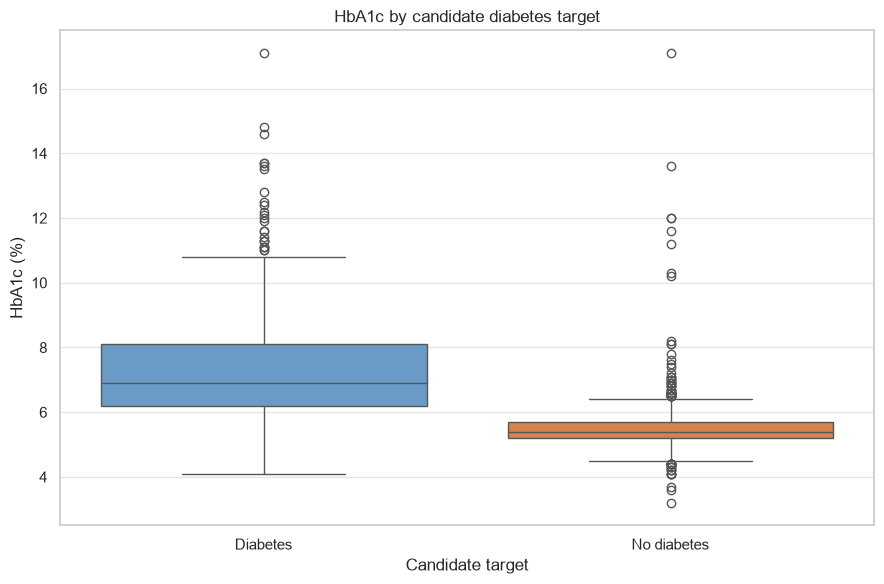

In [24]:
hba1c_target_data = model_analysis_data[[hba1c_column, 'diabetes_target']].dropna().copy()
hba1c_target_data['target_label'] = hba1c_target_data['diabetes_target'].map({0: 'No diabetes', 1: 'Diabetes'})
plt.figure(figsize=(9, 6))
sns.boxplot(data=hba1c_target_data, x='target_label', y=hba1c_column, hue='target_label', legend=False, palette=['#5B9BD5', '#ED7D31'])
plt.xlabel('Candidate target')
plt.ylabel('HbA1c (%)')
plt.title('HbA1c by candidate diabetes target')
plt.tight_layout()
plt.show()